<a href="https://colab.research.google.com/github/SourinaDutta/Chittagonian_Dialect-to-Standard_Bangla/blob/main/NNFL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint


from sklearn.model_selection import train_test_split

In [17]:
#load dataset
main_text = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project/Dataset_Chittagong_2.0.csv', encoding='utf-8')
dict_text = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Project/dictionary.csv', encoding='utf-8')
print("Original Shape:", main_text.shape)
print("Original Shape:", dict_text.shape)
print("Columns in the dataset: ",main_text.columns)
print("Columns in the dataset: ",dict_text.columns)
main_text.head()
# dict_text.head()

Original Shape: (4011, 2)
Original Shape: (1546, 2)
Columns in the dataset:  Index(['বাংলা', 'চট্টগ্রাম'], dtype='object')
Columns in the dataset:  Index(['বাংলা', 'চট্টগ্রাম'], dtype='object')


,বাংলা,চট্টগ্রাম
0,আমি ভাত খাবো না রাগ করছি আমার মনে জ্বালা,অ্যাঁই ভাত ন হাইয়্যুম গুসসা ওইয়্যুম অ্যাঁর মনত...
1,একদিন বুড়ি চিন্তা করল তার মুরগি,একদিন বুড়ি চিন্তা গরিল কুরো
2,আমি যে খেতে দেই যদি,অ্যাঁই যে হাইতে দ্যি যদি
3,সে একটা করে ডিম দেয়,ইতে উজ্ঞো গরে দিম দে
4,তার খাবার দিলে বেশি করে ডিম দিবে,ইতার হানা দিলে বেশি গরে দিম দিতি


EDA

In [18]:
# ----------------- Check Missing Values -----------------
print("\nMissing Values per Column:\n", main_text.isnull().sum())
print("\nMissing Values per Column:\n", dict_text.isnull().sum())
main_text.info()
dict_text.info()
print("\nUnique Values: \n", main_text.nunique())
print("\nUnique Values: \n", dict_text.nunique())


Missing Values per Column:
 বাংলা        0
চট্টগ্রাম    0
dtype: int64

Missing Values per Column:
 বাংলা        1
চট্টগ্রাম    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   বাংলা      4011 non-null   object
 1   চট্টগ্রাম  4011 non-null   object
dtypes: object(2)
memory usage: 62.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   বাংলা      1545 non-null   object
 1   চট্টগ্রাম  1546 non-null   object
dtypes: object(2)
memory usage: 24.3+ KB

Unique Values: 
 বাংলা        4008
চট্টগ্রাম    4007
dtype: int64

Unique Values: 
 বাংলা        1520
চট্টগ্রাম    1515
dtype: int64


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2476 (\N{BENGALI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2434 (\N{BENGALI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/d

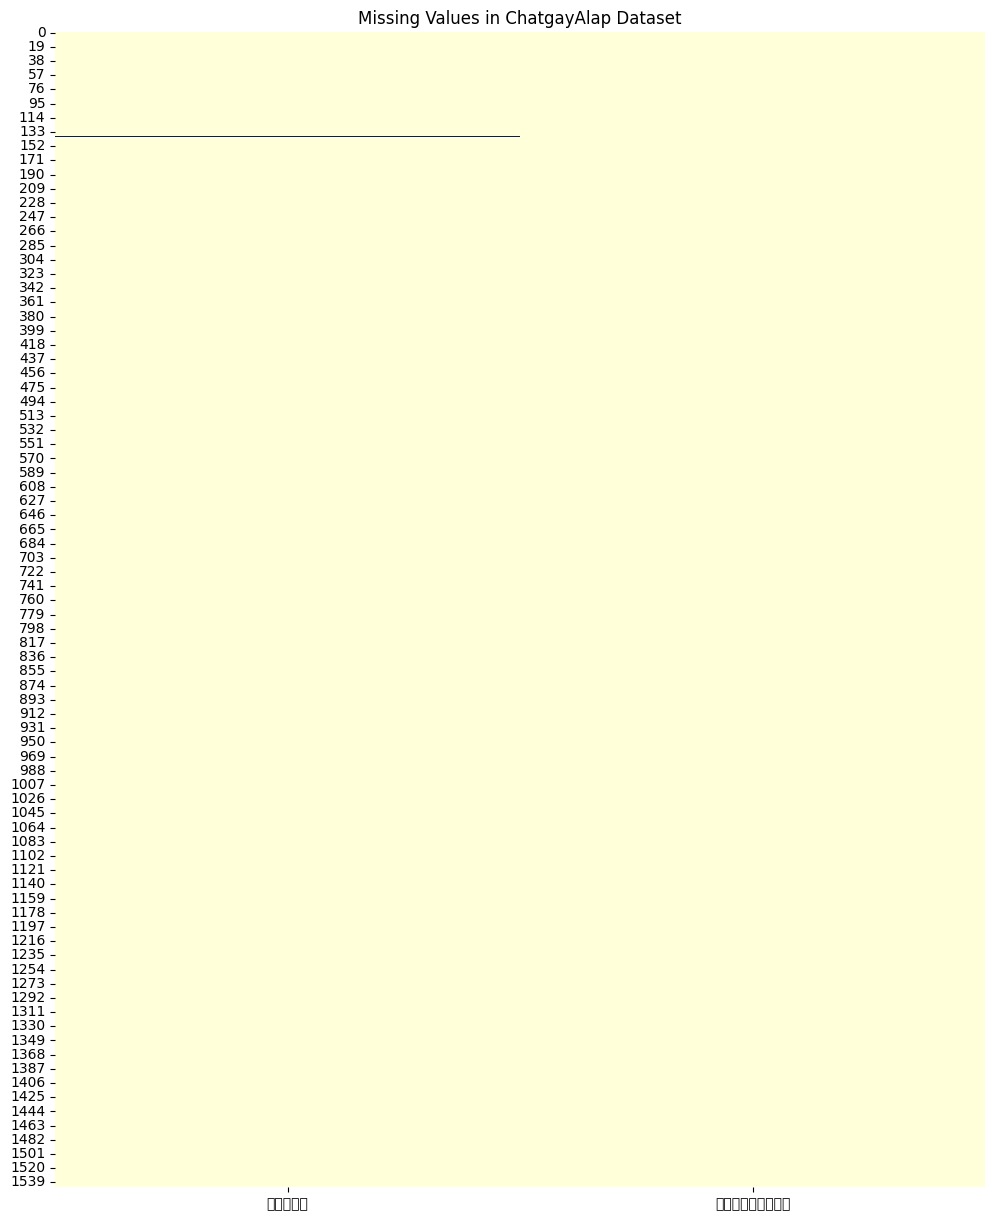


Missing Values per Column:
 বাংলা        1
চট্টগ্রাম    0
dtype: int64


In [19]:
plt.figure(figsize=(12,15))
sns.heatmap(dict_text.isnull(), cbar=False, cmap="YlGnBu")
plt.title("Missing Values in ChatgayAlap Dataset")
plt.show()
print("\nMissing Values per Column:\n", dict_text.isnull().sum())

      len_bangla  len_chatgaiyya
0              9               9
1              6               5
2              5               5
3              5               5
4              7               7
...          ...             ...
4006           4               4
4007           4               4
4008           5               5
4009           6               7
4010           5               5

[4011 rows x 2 columns]
Average length of bangla sentence:  5.336823734729494
Average length of chatgaiyya sentence:  5.322612814759411


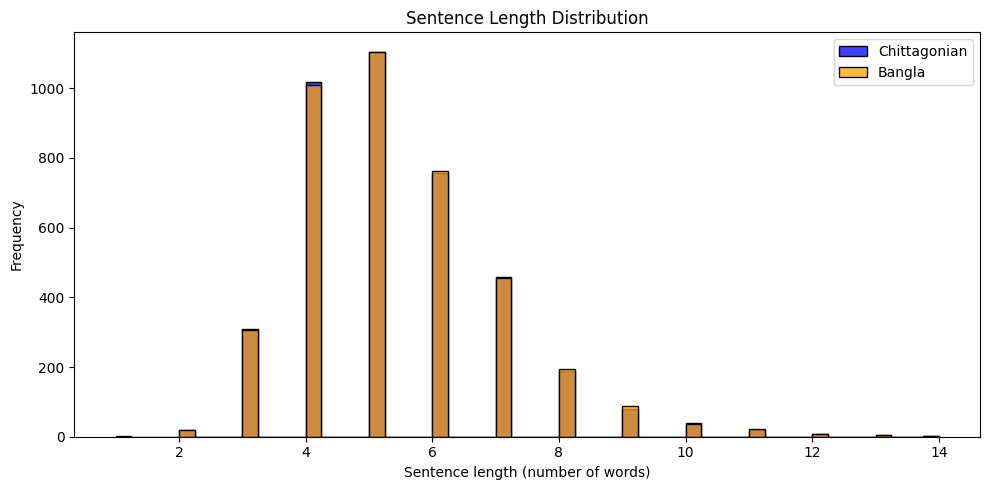

,বাংলা,চট্টগ্রাম,len_bangla,len_chatgaiyya
0,আমি ভাত খাবো না রাগ করছি আমার মনে জ্বালা,অ্যাঁই ভাত ন হাইয়্যুম গুসসা ওইয়্যুম অ্যাঁর মনত...,9,9
1,একদিন বুড়ি চিন্তা করল তার মুরগি,একদিন বুড়ি চিন্তা গরিল কুরো,6,5
2,আমি যে খেতে দেই যদি,অ্যাঁই যে হাইতে দ্যি যদি,5,5
3,সে একটা করে ডিম দেয়,ইতে উজ্ঞো গরে দিম দে,5,5
4,তার খাবার দিলে বেশি করে ডিম দিবে,ইতার হানা দিলে বেশি গরে দিম দিতি,7,7


In [20]:
main_text['len_bangla'] = main_text['বাংলা'].apply(lambda x: len(str(x).split()))
main_text['len_chatgaiyya'] = main_text['চট্টগ্রাম'].apply(lambda x: len(str(x).split()))
print(main_text[['len_bangla', 'len_chatgaiyya']])
avg_len_bangla = main_text['len_bangla'].mean()
avg_len_chatgaiyya = main_text['len_chatgaiyya'].mean()
print("Average length of bangla sentence: ", avg_len_bangla)
print("Average length of chatgaiyya sentence: ", avg_len_chatgaiyya)

plt.figure(figsize=(10,5))
sns.histplot(main_text['len_chatgaiyya'], color='blue', label='Chittagonian')
sns.histplot(main_text['len_bangla'], color='orange', label='Bangla')
plt.title("Sentence Length Distribution", fontsize=12)
plt.xlabel("Sentence length (number of words)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
main_text.head()


Data Cleaning

In [21]:
whitespace = re.compile(u"[\u0020\u00a0\u1680\u180e\u202f\u205f\u3000\u2000-\u200a]+", re.UNICODE)
bangla_fullstop = u"\u0964"  # unicode code for bengali fullstop
punctSeq = u"['\"“”‘’]+|[.…-]+|[:;]+"
bengali_numeral_pattern = r'[০-৯]+'

# Apply regex operations to the 'বাংলা' column
def clean_text(text):
    text = str(text) # Ensure text is a string
    text = re.sub(bengali_numeral_pattern, " ", text)
    text = re.sub(r'\s*\d+\s*', ' ', text)
    text = re.sub('\n'," ", text)
    text = re.sub(punctSeq," ", text)
    text = whitespace.sub(" ", text).strip()
    return text

main_text['processed_বাংলা'] = main_text['বাংলা'].apply(clean_text)

main_text['processed_চট্টগ্রাম'] = main_text['চট্টগ্রাম'].apply(clean_text)
display(main_text.head(20))

,বাংলা,চট্টগ্রাম,len_bangla,len_chatgaiyya,processed_বাংলা,processed_চট্টগ্রাম
0,আমি ভাত খাবো না রাগ করছি আমার মনে জ্বালা,অ্যাঁই ভাত ন হাইয়্যুম গুসসা ওইয়্যুম অ্যাঁর মনত...,9,9,আমি ভাত খাবো না রাগ করছি আমার মনে জ্বালা,অ্যাঁই ভাত ন হাইয়্যুম গুসসা ওইয়্যুম অ্যাঁর মনত...
1,একদিন বুড়ি চিন্তা করল তার মুরগি,একদিন বুড়ি চিন্তা গরিল কুরো,6,5,একদিন বুড়ি চিন্তা করল তার মুরগি,একদিন বুড়ি চিন্তা গরিল কুরো
2,আমি যে খেতে দেই যদি,অ্যাঁই যে হাইতে দ্যি যদি,5,5,আমি যে খেতে দেই যদি,অ্যাঁই যে হাইতে দ্যি যদি
3,সে একটা করে ডিম দেয়,ইতে উজ্ঞো গরে দিম দে,5,5,সে একটা করে ডিম দেয়,ইতে উজ্ঞো গরে দিম দে
4,তার খাবার দিলে বেশি করে ডিম দিবে,ইতার হানা দিলে বেশি গরে দিম দিতি,7,7,তার খাবার দিলে বেশি করে ডিম দিবে,ইতার হানা দিলে বেশি গরে দিম দিতি
5,আর আমার বেশি টাকা ঘরে আসবে,আর অ্যাঁর বেশি টিঁয়া ঘরত আইব্যু,6,6,আর আমার বেশি টাকা ঘরে আসবে,আর অ্যাঁর বেশি টিঁয়া ঘরত আইব্যু
6,বুড়ি মুরগির খাওয়া বেশি করে দেয়,বুড়ি কুরোর হাওন বেশি গরে দে,6,6,বুড়ি মুরগির খাওয়া বেশি করে দেয়,বুড়ি কুরোর হাওন বেশি গরে দে
7,মুরগি বেশি খাবার খেয়ে বেশি করে ডিম দেয়,কুরো বেশি হানা হাই বেশি গরে দিম দে,8,8,মুরগি বেশি খাবার খেয়ে বেশি করে ডিম দেয়,কুরো বেশি হানা হাই বেশি গরে দিম দে
8,কিন্তু পরের দিন আর ডিম দেয় না,কিন্তু ফরর দিন আর দিম ন দে,7,7,কিন্তু পরের দিন আর ডিম দেয় না,কিন্তু ফরর দিন আর দিম ন দে
9,আবার ডিম দিয়েছে মুরগি,আবার দিম দিইয়্যি কুরো,4,4,আবার ডিম দিয়েছে মুরগি,আবার দিম দিইয়্যি কুরো


Tokenization

In [22]:
bangla_text = main_text['processed_বাংলা'].astype(str).tolist()
chatgaiyya_text = main_text['processed_চট্টগ্রাম'].astype(str).tolist()

input_tokenizer = Tokenizer(oov_token="<OOV>")
input_tokenizer.fit_on_texts(chatgaiyya_text)
input_sequences = input_tokenizer.texts_to_sequences(chatgaiyya_text)

target_tokenizer = Tokenizer(oov_token="<OOV>")
target_tokenizer.fit_on_texts(bangla_text)
target_sequences = target_tokenizer.texts_to_sequences(bangla_text)

# Sequence length
max_input_len = max(len(seq) for seq in input_sequences)
max_target_len = max(len(seq) for seq in target_sequences)
max_seq_len = max(max_input_len, max_target_len)

# Padding (only once)
X = pad_sequences(input_sequences, maxlen=max_seq_len, padding='post')
Y = pad_sequences(target_sequences, maxlen=max_seq_len, padding='post')

print("Shapes:", X.shape, Y.shape)

print("\nExample:")
print("Original Chatgaiya language:", chatgaiyya_text[0])
print("Tokenized:", input_sequences[0][:10], "...")
print("Original Bangla language:", bangla_text[0])
print("Tokenized:", target_sequences[0][:10])

Shapes: (4011, 14) (4011, 14)

Example:
Original Chatgaiya language: অ্যাঁই ভাত ন হাইয়্যুম গুসসা ওইয়্যুম অ্যাঁর মনত জ্বালা
Tokenized: [3, 161, 2, 226, 130, 1104, 4, 30, 550] ...
Original Bangla language: আমি ভাত খাবো না রাগ করছি আমার মনে জ্বালা
Tokenized: [3, 161, 229, 2, 124, 293, 4, 27, 550]


Train/Test Split

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.2, #20% testing and 80% training
    random_state = 42,
    shuffle = True
)

print("Training data_shape: ", X_train.shape, Y_train.shape)
print("\nTesting data_shape: ", X_test.shape, Y_test.shape)

print("\nExample from train set:")
print("X_train[0]:", X_train[0][:15])  # প্রথম ১৫টা টোকেন দেখাচ্ছে
print("Y_train[0]:", Y_train[0][:15])

Training data_shape:  (3208, 14) (3208, 14)

Testing data_shape:  (803, 14) (803, 14)

Example from train set:
X_train[0]: [374 154   2 234   0   0   0   0   0   0   0   0   0   0]
Y_train[0]: [379 293 225   2   0   0   0   0   0   0   0   0   0   0]


Custom RNN model

In [25]:
input_word_size = len(input_tokenizer.word_index) + 1
target_word_size = len(target_tokenizer.word_index) + 1

model = Sequential([
    Embedding(input_dim=input_word_size, output_dim=128, input_length=max_seq_len, mask_zero=True),
    SimpleRNN(units=256, return_sequences=True),
    Dropout(0.2),
    Dense(target_word_size, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

model.build(input_shape=(None, max_seq_len))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 14, 128)        │       371,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 14, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14, 2762)       │       709,834 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,179,850 (4.50 MB)

 Trainable params: 1,179,850 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

Training the Model

In [26]:
checkpoint = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history = model.fit(
    X, Y,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint]
)


Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0333 - loss: 7.6486
Epoch 1: val_loss improved from inf to 6.76934, saving model to best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.0334 - loss: 7.6433 - val_accuracy: 0.0271 - val_loss: 6.7693
Epoch 2/50
47/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0322 - loss: 6.6124
Epoch 2: val_loss improved from 6.76934 to 6.03179, saving model to best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0322 - loss: 6.5969 - val_accuracy: 0.0366 - val_loss: 6.0318
Epoch 3/50
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0516 - loss: 5.7492
Epoch 3: val_loss improved from 6.03179 to 5.29443, saving model to best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0522 - loss: 5.7421 - val_accuracy: 0.0801 - val_loss: 5.2944
Epoch 4/50
45/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0938 - loss: 5.0423
Epoch 4: val_loss improved from 5.29443 to 4.60169, saving model

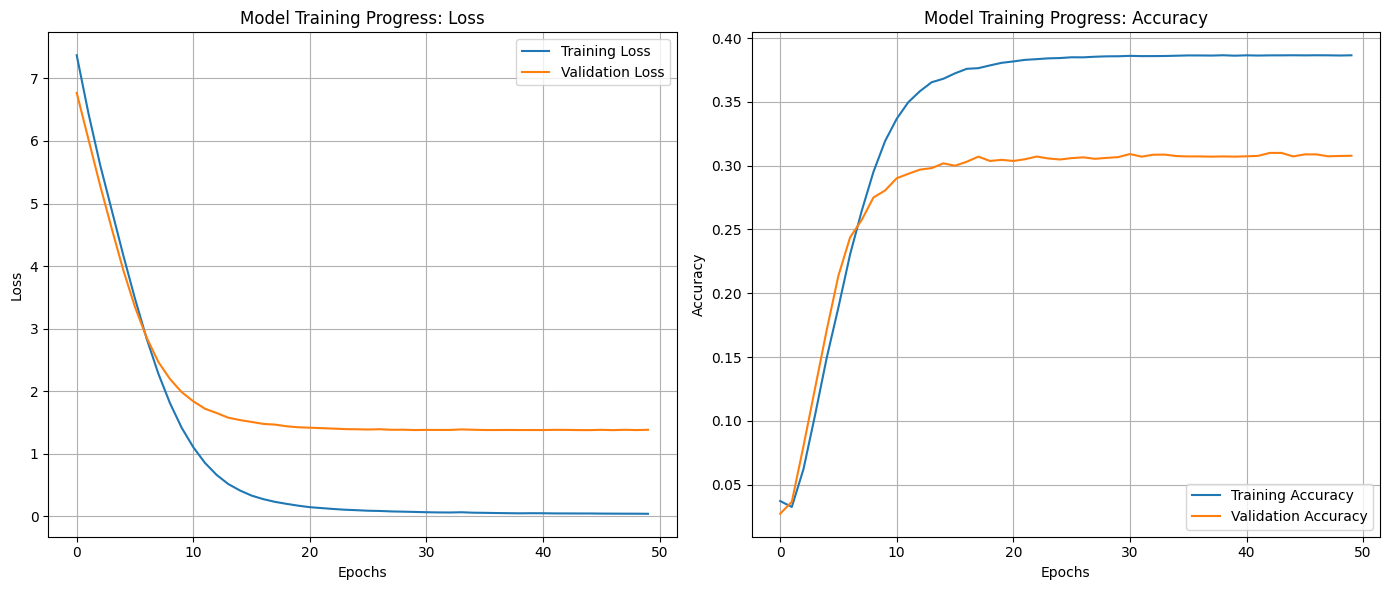

In [27]:
plt.figure(figsize=(14, 6))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Progress: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Training Progress: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Prediction

In [28]:
def translate_sentence(ip_sentence):
    ip_sentence = ip_sentence.strip()
    ip_sequence = input_tokenizer.texts_to_sequences([ip_sentence])
    ip_padded = pad_sequences(ip_sequence, maxlen=len(ip_sentence), padding='post')

    prediction = model.predict(ip_padded)
    predicted_indices = np.argmax(prediction[0], axis=1)

    reverse_target_index = {v: k for k, v in target_tokenizer.word_index.items()}

    predicted_words_raw = [
        reverse_target_index.get(idx, '')
        for idx in predicted_indices
        if idx != 0
    ]

    predicted_words_filtered = []
    for word in predicted_words_raw:
        if not predicted_words_filtered or predicted_words_filtered[-1] != word:
            predicted_words_filtered.append(word)

    return " ".join(predicted_words_filtered)


test = "অ্যাঁই আর ন গইজ্জুম আজিয়ে কিসু, অ্যাঁর আজিয়ে মন গম নাই"
translated = translate_sentence(test)

print("Test Sentence:", test)
print("\nTranslated sentence: ", translated)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Test Sentence: অ্যাঁই আর ন গইজ্জুম আজিয়ে কিসু, অ্যাঁর আজিয়ে মন গম নাই

Translated sentence:  আমি আর করবো না আজকে কিছু আমার আজকে মন ভাল নেই
